#  Medical Insurance Cost Prediction project


The main goal of this project is to predict the medical insurance charges of a person based on personal and lifestyle information such as:

    Age

    Gender

    BMI

    Number of children

    Smoking habits

    Region

Using these features, the model predicts how much insurance cost (charges) a person may need to pay.

### 1.Importing the libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

    Imports the NumPy library

    Used for numerical calculations like arrays , mathematical operations.
    
import pandas as pd 

    Imports Pandas library

    Used to load and manipulate datasets like Read CSV files and Handle tables (DataFrames)
    
import matplotlib.pyplot as plt

    used for data visualization .

### 2.Load the dataset (Data Collection).

In [5]:
df = pd.read_csv("Medical Insurance Cost Prediction_dataset.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


### 3.Data Analysis

In [6]:
df.shape

(1338, 7)

Number of rows and columns .

In [12]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


head() is used to display the first 5 rows of a dataset to quickly view and understand the data structure

In [13]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


tail() is used to display the last 5 rows of a dataset, helping us quickly view the ending records of the data.

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


info() is used to display a summary of the dataset including column names, data types, number of non-null values, and memory usage.

It provides important information about the structure of the data.


#### Categorical Columns

     Sex
     
     Smoker
     
     Region

In [15]:
# Checking for missing values

df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Checks if any column has missing values.

There is no missing values.

In [16]:
# Statistical Measure of the dataset

df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


describe() is used to display statistical summary of numerical columns such as count, mean, standard deviation, minimum, maximum, and quartile values.

### 4.Data visualization

#### Age Distribution.

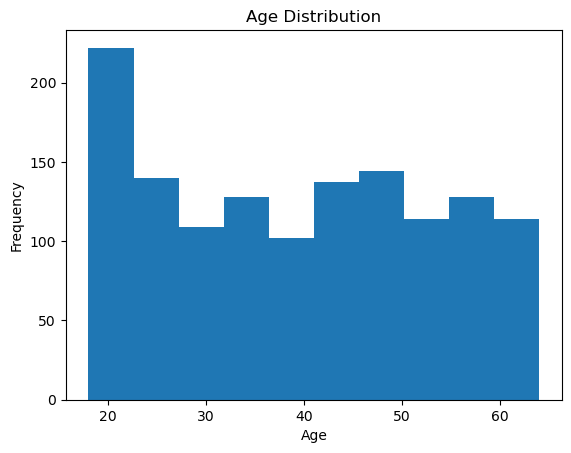

In [18]:
plt.hist(df['age'])
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

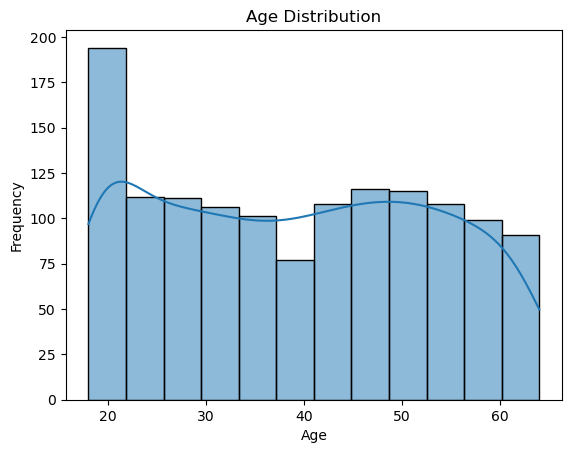

In [36]:
sns.histplot(df['age'],kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

Shows age distribution of people.

Most people are between 20-50 years.

#### Gender Distribution

Counts number of males and females

In [19]:
df['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

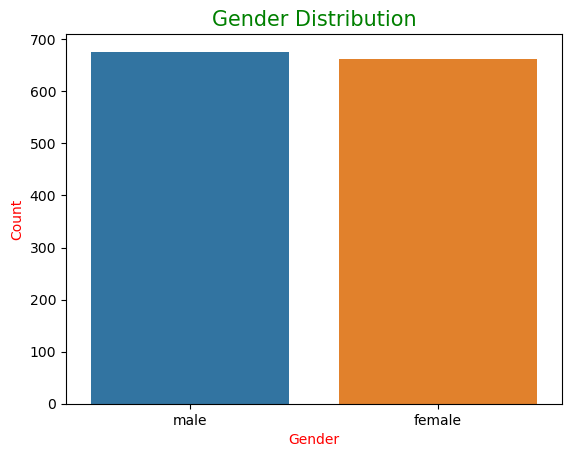

In [31]:
sns.barplot(x=df['sex'].value_counts().index,
            y=df['sex'].value_counts().values)
plt.title("Gender Distribution",size =15,color='g')
plt.xlabel("Gender",color='r')
plt.ylabel("Count",color='r')
plt.show()

#### BMI Distribution.

Shows BMI values of customers.

C:\Users\kiran\AppData\Local\Temp\ipykernel_6568\2252599731.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bmi'])


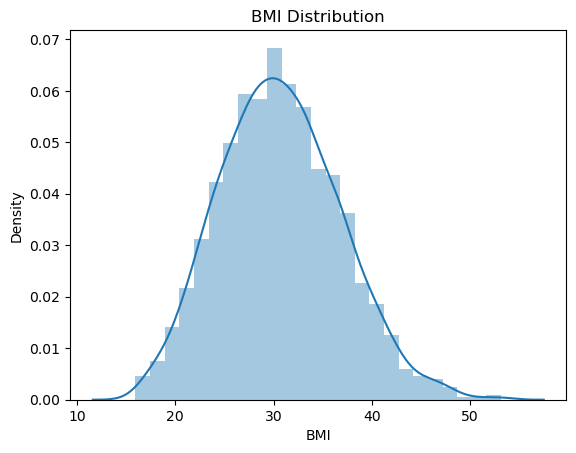

In [8]:
sns.distplot(df['bmi'])
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Density")
plt.show()

Normal BMI range:

18.5 – 24.9

#### Children Distribution.

Shows how many children customers have.

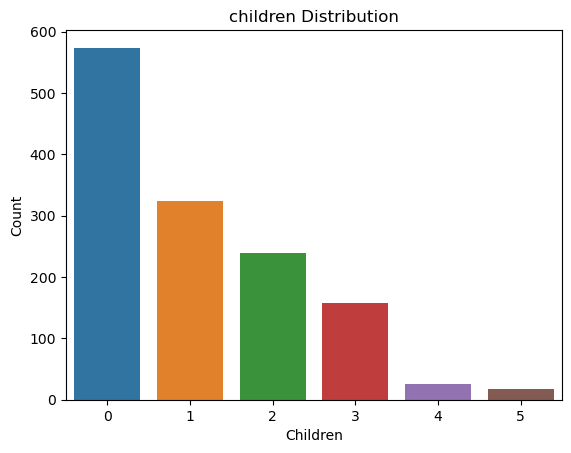

In [7]:
sns.countplot(x='children', data=df)
plt.xlabel("Children")
plt.ylabel("Count")
plt.title("children Distribution")
plt.show()

In [46]:
df['children'].value_counts()

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

#### Smoker Distribution

Shows number of smokers vs non-smokers.

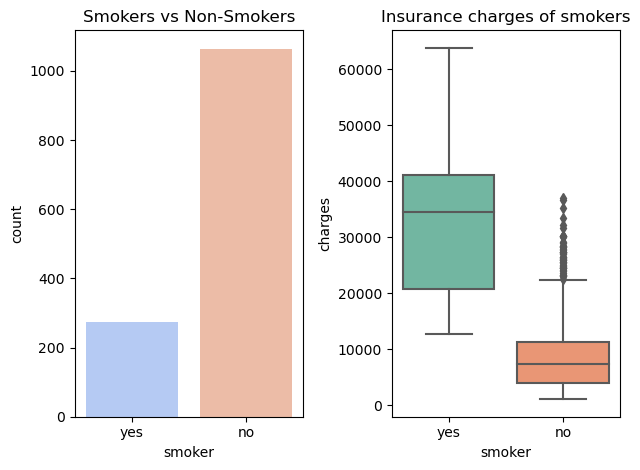

In [72]:
fig,ax=plt.subplots(1,2)
sns.countplot(x='smoker',data=df,ax=ax[0],palette='coolwarm')
ax[0].set_title("Smokers vs Non-Smokers")

sns.boxplot(x='smoker',y='charges',data=df,ax=ax[1],palette='Set2')
ax[1].set_title("Insurance charges of smokers")
plt.tight_layout()

plt.show()



In [49]:
df['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

Smokers usually have higher insurance costs.

#### Region Distribution

 Shows customers from regions like:

southeast

southwest

northeast

northwest

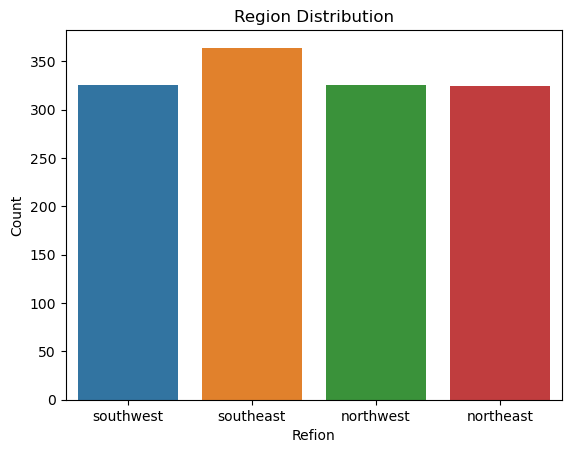

In [52]:
sns.countplot(x='region',data=df)
plt.xlabel("Refion")
plt.ylabel("Count")
plt.title("Region Distribution")
plt.show()

In [53]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

#### Charges Distribution

Shows distribution of insurance costs

C:\Users\kiran\AppData\Local\Temp\ipykernel_11228\3861740323.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['charges'])


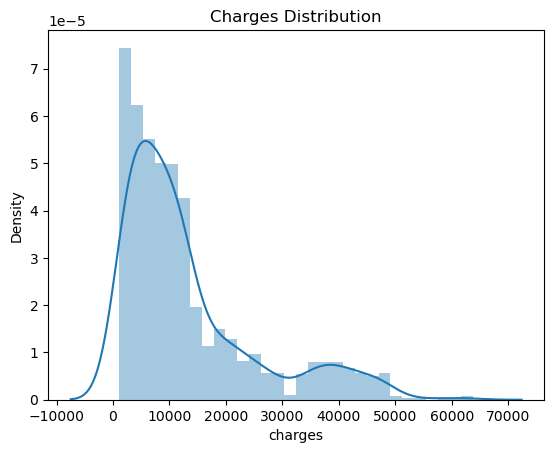

In [74]:
sns.distplot(df['charges'])
plt.title("Charges Distribution")
plt.show()

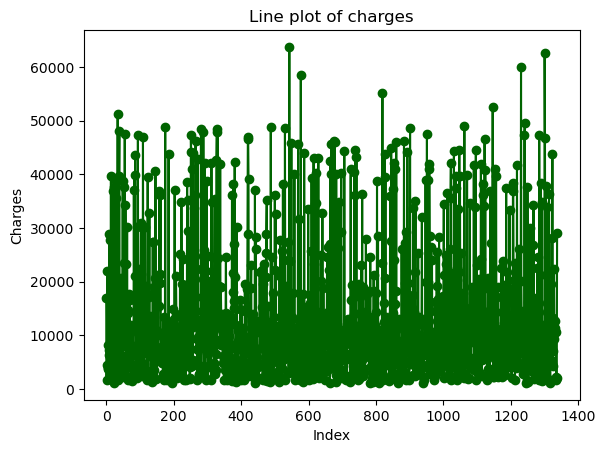

In [5]:
plt.plot(df['charges'],marker='o',color='darkgreen')
plt.title("Line plot of charges")
plt.xlabel("Index")
plt.ylabel("Charges")
plt.show()

##  Data Prepocessing

Encoding Chategorical features

In [8]:
#encoding sex column
df.replace({'sex':{'male':0,'female':1}},inplace=True)

#encoding smoker column
df.replace({'smoker':{'yes':0,'no':1}},inplace=True)

#encoding region column
df.replace({'region':{'southeast':0,'southwest':1,'northeast':2,'northwest':3}},inplace=True)
df

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,0,1,16884.92400
1,18,0,33.770,1,1,0,1725.55230
2,28,0,33.000,3,1,0,4449.46200
3,33,0,22.705,0,1,3,21984.47061
4,32,0,28.880,0,1,3,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,1,3,10600.54830
1334,18,1,31.920,0,1,2,2205.98080
1335,18,1,36.850,0,1,0,1629.83350
1336,21,1,25.800,0,1,1,2007.94500


#### Feature & Target Split

In [11]:
X = df.drop(columns='charges', axis=1)
y = df['charges']
df

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,0,1,16884.92400
1,18,0,33.770,1,1,0,1725.55230
2,28,0,33.000,3,1,0,4449.46200
3,33,0,22.705,0,1,3,21984.47061
4,32,0,28.880,0,1,3,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,1,3,10600.54830
1334,18,1,31.920,0,1,2,2205.98080
1335,18,1,36.850,0,1,0,1629.83350
1336,21,1,25.800,0,1,1,2007.94500


## Train-Test Split

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Feature Scaling

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Machine Learning Algorithms

In [14]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

## Models Initialization

In [16]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100),
    "Gradient Boosting": GradientBoostingRegressor(),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor()
}

## Training & Evaluation

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = (mse, mae, r2)

    print(f"{name}")
    print(f" MSE: {mse:.2f}")
    print(f" MAE: {mae:.2f}")
    print(f" R2 Score: {r2:.4f}")
    print("-"*30)

Linear Regression
 MSE: 33685623.35
 MAE: 4190.22
 R2 Score: 0.7830
------------------------------
Ridge
 MSE: 33693419.49
 MAE: 4191.96
 R2 Score: 0.7830
------------------------------
Lasso
 MSE: 33689145.48
 MAE: 4190.47
 R2 Score: 0.7830
------------------------------
Decision Tree
 MSE: 48412957.88
 MAE: 3402.15
 R2 Score: 0.6882
------------------------------
Random Forest
 MSE: 20207897.56
 MAE: 2467.54
 R2 Score: 0.8698
------------------------------
Gradient Boosting
 MSE: 18652415.38
 MAE: 2402.27
 R2 Score: 0.8799
------------------------------
SVR
 MSE: 165926860.21
 MAE: 8600.16
 R2 Score: -0.0688
------------------------------
KNN
 MSE: 25945670.36
 MAE: 3079.20
 R2 Score: 0.8329
------------------------------


## Best Model Selection

In [18]:
best_model_name = max(results, key=lambda x: results[x][2])
best_model = models[best_model_name]

print(f"Best Model: {best_model_name}")

Best Model: Gradient Boosting


## Prediction system

In [19]:
sample = np.array([[33, 0, 22.705, 0, 1, 3]])
sample = scaler.transform(sample)

prediction = best_model.predict(sample)

print(f"Predicted Insurance Cost: {prediction[0]:.2f}")

Predicted Insurance Cost: 6363.42


C:\Users\kiran\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
